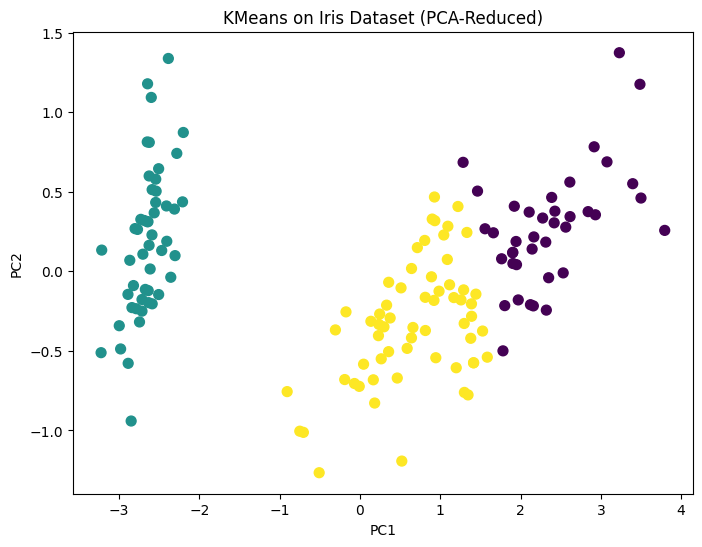

In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 加载数据
iris = load_iris()
X = iris.data

# 聚类
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# 可视化（先降维）
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title('KMeans on Iris Dataset (PCA-Reduced)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

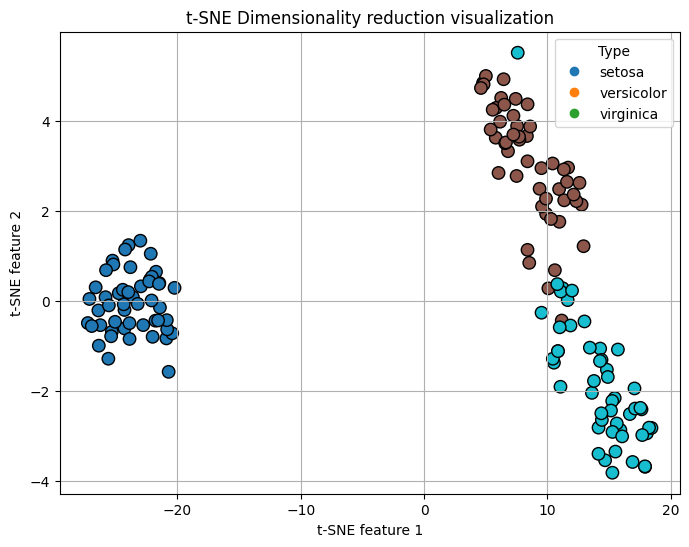

In [ ]:
# t-SNE 可视化
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. 加载数据
iris = load_iris()
X = iris.data  # 原始特征 (4维)
y = iris.target  # 类别标签 (0, 1, 2)

# 2. 使用 t-SNE 降维到 2 维
# 参数解释：
# n_components: 降维后的维度，这里设置为 2。
# random_state: 随机种子，确保结果可复现。
# perplexity: t-SNE 的一个重要参数，通常在 5 到 50 之间，影响局部和全局结构的平衡。主要作用是控制每个点的有效邻居数量，较小的 perplexity 会更关注局部结构，而较大的 perplexity 会更关注全局结构。

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# 3. 绘图
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', edgecolor='k', s=80)
plt.title("t-SNE Dimensionality reduction visualization")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.grid(True)

# 4. 添加图例
legend_labels = iris.target_names
handles = [plt.Line2D([], [], marker="o", linestyle="", label=label, color=plt.cm.tab10(i)) 
           for i, label in enumerate(legend_labels)]
plt.legend(handles=handles, title="Type")

plt.show()

In [ ]:
# UMAP 可视化
import umap
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. 加载数据
iris = load_iris()
X = iris.data  # 原始特征：4维
y = iris.target  # 类别标签：0, 1, 2
target_names = iris.target_names

# 2. UMAP 降维：将 4 维特征压缩到 2 维
reducer = umap.UMAP(
    n_neighbors=15,   # 局部近邻数，决定局部结构保留程度
    min_dist=0.1,     # 最小距离，越小图像越紧凑
    random_state=42   # 固定随机数，结果可复现
)
X_umap = reducer.fit_transform(X)

# 3. 可视化
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=80, edgecolor='k')
plt.title("UMAP Dimensionality reduction visualization (Iris)")
plt.xlabel("UMAP feature 1")
plt.ylabel("UMAP feature 2")
plt.grid(True)

# 4. 添加图例
handles = [
    plt.Line2D([], [], marker='o', color='w', label=label,
               markerfacecolor=plt.cm.tab10(i), markersize=10, markeredgecolor='k')
    for i, label in enumerate(target_names)
]
plt.legend(handles=handles, title="Type")

plt.show()

ModuleNotFoundError: No module named 'umap'